Rodrigo García Salado

---
### PRÁCTICA 2
---

Ponemos los imports

In [109]:
#imports

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score



Importamos el archivo

In [110]:
# Cargamos el archivo
data_df = pd.read_csv("stars_data.csv") 

Ahora observamos cuantos y qué tipo de datos vamos a estar tratando


In [111]:

print('The shape of the data table is:')
print('===============================')
print(data_df.shape)
print()

print('The types of the attributes are:')
print('================================')
data_df.info()

print()

print('How many missing values per attribute:')
print('======================================')
print(data_df.isnull().sum())

print()

print('Fraction of missing values per attribute:')
print('======================================')
print(data_df.isnull().mean())


The shape of the data table is:
(240, 6)

The types of the attributes are:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    object 
 5   Spectral_Class  240 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 11.4+ KB

How many missing values per attribute:
Temperature       0
L                 0
R                 0
A_M               0
Color             0
Spectral_Class    0
dtype: int64

Fraction of missing values per attribute:
Temperature       0.0
L                 0.0
R                 0.0
A_M               0.0
Color             0.0
Spectral_Class    0.0
dtype: float64


In [112]:
SEMILLA = 100478705

# Lista de scalers a comparar
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}



Debemos agrupar la variable categórica, por lo que lo haremos a partir de la media de su temperatura correspondiente

In [113]:
y = data_df['Spectral_Class'] 

# Orden lógico basado en temperatura
orden_color = data_df.groupby('Color')['Temperature'].mean().sort_values().index
orden_spectral = data_df.groupby('Spectral_Class')['Temperature'].mean().sort_values().index

mapa_color = {c: i for i, c in enumerate(orden_color)}
mapa_spectral = {c: i for i, c in enumerate(orden_spectral)}

data_df['Color'] = data_df['Color'].map(mapa_color)
data_df['Spectral_Class'] = data_df['Spectral_Class'].map(mapa_spectral)

# X para clustering (quitamos la etiqueta)
X = data_df.drop(columns=['Spectral_Class'])
y_numerico = data_df['Spectral_Class']

creamos la figura para comparar

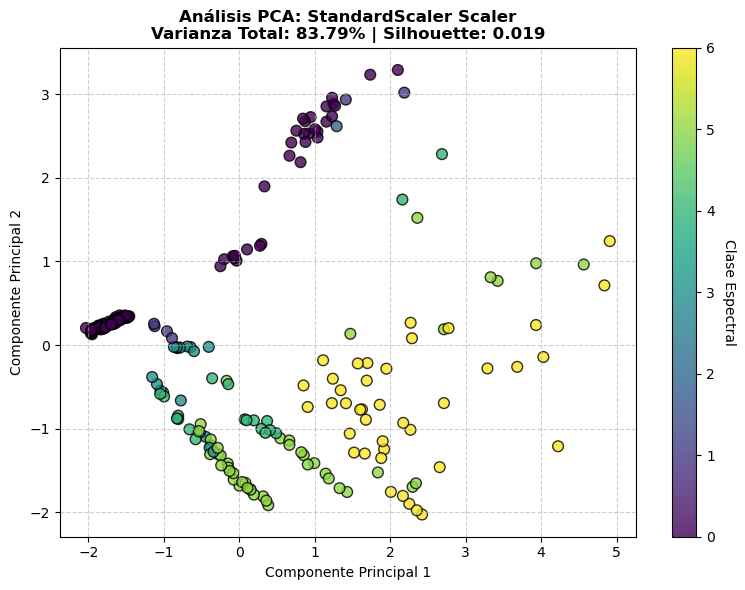

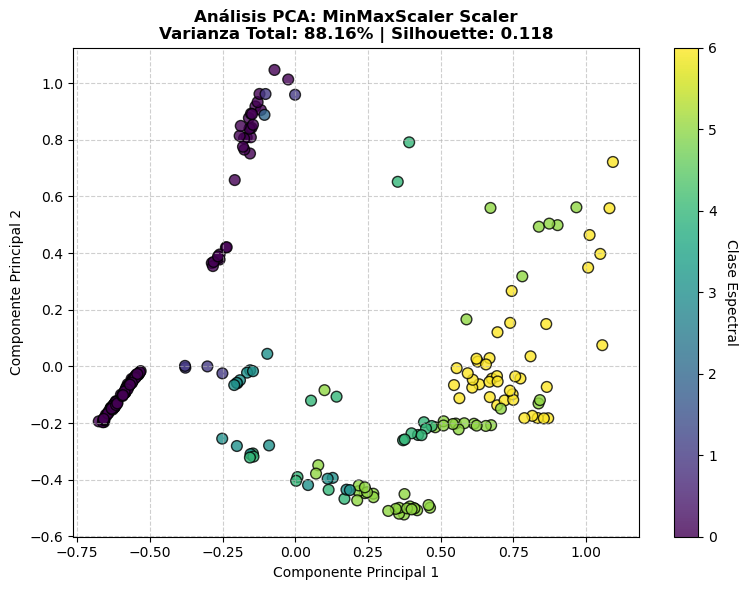

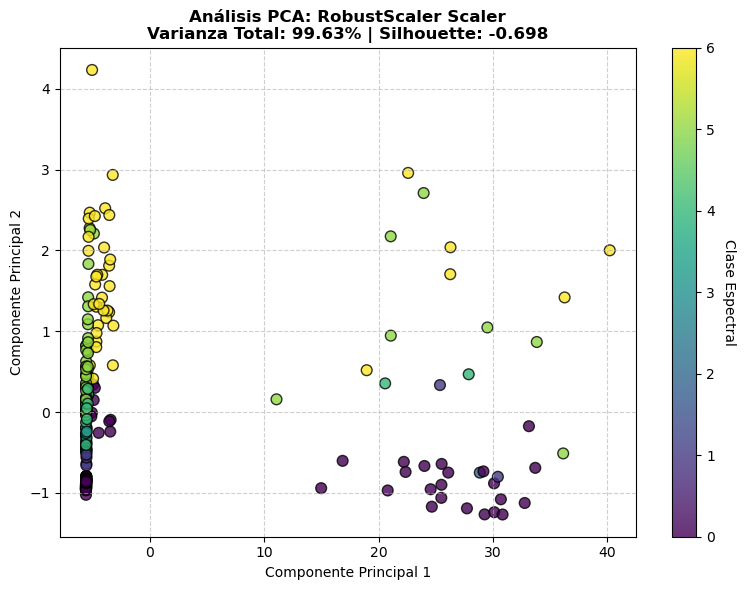

------------------------------
RESUMEN DE COMPARACIÓN:
StandardScaler: Varianza=83.79%, Silhouette=0.019
MinMaxScaler: Varianza=88.16%, Silhouette=0.118
RobustScaler: Varianza=99.63%, Silhouette=-0.698


In [114]:

# Diccionario para guardar el rendimiento de cada scaler
resultados_analisis = {}

# Definimos las clases reales para la leyenda (basado en tu dataframe original)
nombres_clases = data_df['Spectral_Class'].unique() # Asegúrate de usar el df con texto

for name, scaler in scalers.items():
    # 1. Pipeline: Escalado + PCA
    pipeline = Pipeline([
        ('scaler', scaler),
        ('pca', PCA(n_components=2, random_state=SEMILLA))
    ])

    X_pca = pipeline.fit_transform(X)
    pca_obj = pipeline.named_steps['pca']
    
    # Cálculo de Varianza
    total_explained = np.sum(pca_obj.explained_variance_ratio_)
    
    # Métrica Silhouette Score
    score_sil = silhouette_score(X_pca, y_numerico)
    
    # Guardamos para comparar luego
    resultados_analisis[name] = {'varianza': total_explained, 'silhouette': score_sil}

    # Graficado
    plt.figure(figsize=(8, 6))
    
    # Scatter plot
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_numerico, cmap='viridis', edgecolor='k', s=60, alpha=0.8)
    
    # Añadimos barra de colores con nombres de las clases
    cbar = plt.colorbar(scatter)
    cbar.set_label('Clase Espectral', rotation=270, labelpad=15)
    
    # Título dinámico con métricas
    plt.title(f'Análisis PCA: {name} Scaler\n'
              f'Varianza Total: {total_explained:.2%} | Silhouette: {score_sil:.3f}', 
              fontsize=12, fontweight='bold')
    
    plt.xlabel('Componente Principal 1')
    plt.ylabel('Componente Principal 2')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Resumen de resultados
print("-" * 30)
print("RESUMEN DE COMPARACIÓN:")
for s, m in resultados_analisis.items():
    print(f"{s}: Varianza={m['varianza']:.2%}, Silhouette={m['silhouette']:.3f}")

FALTA POR DECIR XQ ESTE ESCALADO##########################################

In [115]:
# Escalado con MinMax
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Reducción con PCA a 2 componentes
pca = PCA(n_components=2, random_state=SEMILLA)
X_pca = pca.fit_transform(X_scaled)

# K-means

Primero medimos el numero de clusters

In [116]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=SEMILLA)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_pca, kmeans.labels_))





Medimos la inercia mediante el metodo del codo

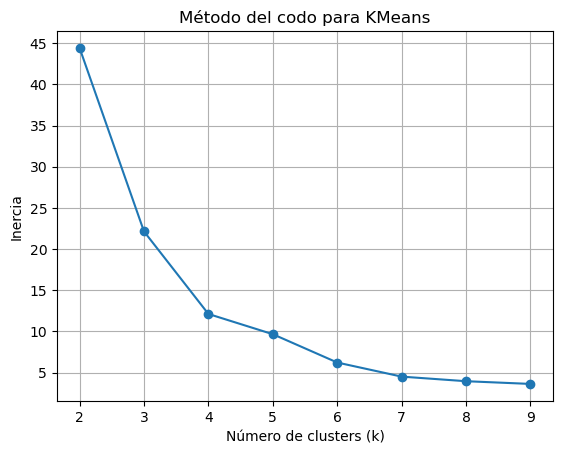

In [117]:
# Gráfico del método del codo
plt.figure()
plt.plot(K, inertia, 'o-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo para KMeans')
plt.grid()
plt.show()

Y la distancia entre un cluster y otro por medio del coeficiente de silueta

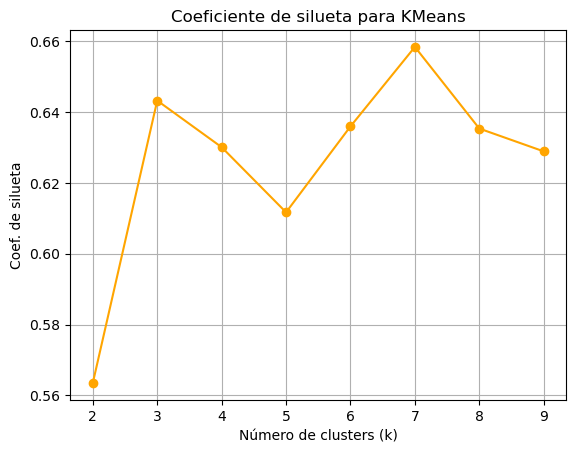

k   |  silhouette
------------------
 2  |  0.5635
 3  |  0.6432
 4  |  0.6301
 5  |  0.6117
 6  |  0.6359
 7  |  0.6584
 8  |  0.6353
 9  |  0.6289

Silhouette para k = 3  0.6432
Máximo global: k = 7  (silhouette = 0.6584)


In [118]:
# Gráfico del coeficiente de silueta
plt.figure()
plt.plot(K, silhouette, 'o-', color='orange')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Coef. de silueta')
plt.title('Coeficiente de silueta para KMeans')
plt.grid()
plt.show()


print("k   |  silhouette")
print("------------------")
for k, sil in zip(K, silhouette):
    print(f"{k:>2}  |  {sil:.4f}")

# · Silhouette concreta para k = 3
sil_k3 = silhouette[K.index(3)]
print(f"\nSilhouette para k = 3  {sil_k3:.4f}")

# · Mejor k según la métrica
best_idx = np.argmax(silhouette)
print(f"Máximo global: k = {K[best_idx]}  (silhouette = {silhouette[best_idx]:.4f})")


Aunque el valor más alto del coeficiente de silueta se obtiene con k=7, el método del codo muestra claramente un punto de inflexión entre k = 3 y k = 4, donde la inercia comienza a disminuir. El aumento del silhouette de k = 7 respecto al K = 3 es muy pequeño en relacion al aumento en los clusters, por lo que nos quedaremos con el K = 3.

El valor de silueta en k=3 sigue siendo razonablemente alto, lo que sugiere una buena separación entre los clusters. Por tanto, optamos por aplicar KMeans con k=3

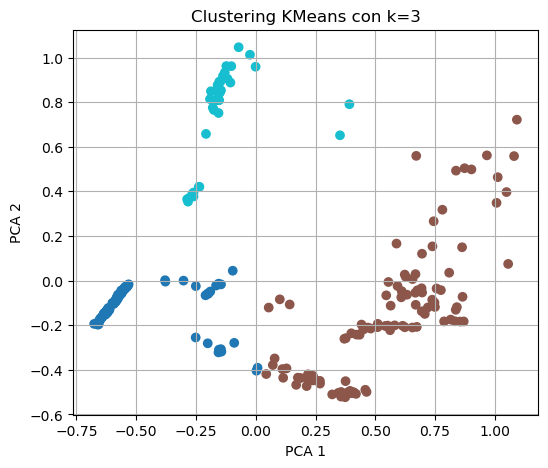

In [119]:
k_opt = 3

kmeans = KMeans(n_clusters=k_opt, random_state=SEMILLA)
kmeans_labels = kmeans.fit_predict(X_pca)

# Visualizar los clusters encontrados
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab10')
plt.title(f'Clustering KMeans con k={k_opt}')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid()
plt.show()


# Clustering jerárquico / aglomerativo

Comparamos funciones de linkages con numeros de clusters para quedarnos con el mejor

In [120]:
linkages = ['ward', 'complete', 'average', 'single']
k_range  = range(2, 10)
results  = []

for link in linkages:
    for k in k_range:
        labels = AgglomerativeClustering(n_clusters=k, linkage=link).fit_predict(X_pca)
        sil = silhouette_score(X_pca, labels) if len(np.unique(labels)) > 1 else np.nan
        results.append((link, k, sil))

res_df = pd.DataFrame(results, columns=['linkage', 'k', 'silhouette'])
best_link, best_k = res_df.loc[res_df['silhouette'].idxmax(), ['linkage', 'k']]

print(f"Mejor -> linkage = {best_link}, k = {best_k}, silhouette = "
      f"{res_df['silhouette'].max():.4f}")
display(res_df.pivot(index='linkage', columns='k', values='silhouette'))


Mejor -> linkage = average, k = 8, silhouette = 0.6605


k,2,3,4,5,6,7,8,9
linkage,,,,,,,,
average,0.556043,0.637420,0.612136,0.594001,0.611222,0.602802,0.660532,0.629451
complete,0.439456,0.484476,0.605719,0.616611,0.607083,0.638164,0.646164,0.617355
single,0.368801,0.270955,0.113009,-0.097778,-0.148720,0.320734,0.482060,0.555338
ward,0.556043,0.637420,0.605772,0.626546,0.635349,0.653119,0.616235,0.624630


Tras analizar los resultados hemos seleccionado el método de enlace 'average' con k=8 clusters. 

Esta combinación presenta el coeficiente de Silhouette más elevado de la comparativa (0.660), lo que indica una estructura de agrupamiento con la mejor relación entre cohesión interna y separación. A diferencia del enlace 'single', que muestra un rendimiento deficiente, el enlace 'average' logra equilibrar las distancias entre todos los miembros de los grupos.

Ahora mostramos en una gráfica cómo se han agrupado los datos:

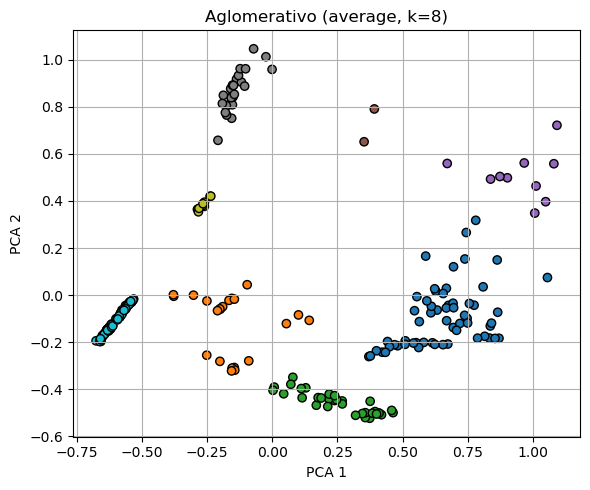

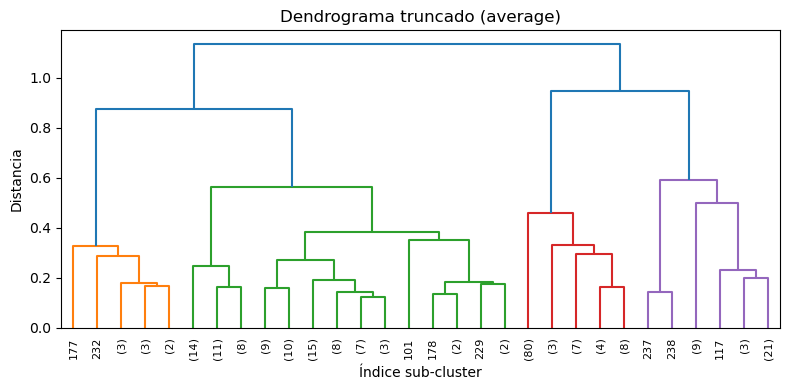

In [121]:

best_labels = AgglomerativeClustering(n_clusters=best_k, linkage=best_link).fit_predict(X_pca)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels, cmap='tab10', edgecolor='k')
plt.title(f'Aglomerativo ({best_link}, k={best_k})')
plt.xlabel('PCA 1'); plt.ylabel('PCA 2'); plt.grid(); plt.tight_layout()
plt.show()

Z = linkage(X_pca, method=best_link)
plt.figure(figsize=(8, 4))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=8.)
plt.title(f'Dendrograma truncado ({best_link})')
plt.xlabel('Índice sub-cluster'); plt.ylabel('Distancia'); plt.tight_layout()
plt.show()


# DBSCAN

Lo primero es elegir el min_samples, para ello hemos hecho uso de 2 x D siendo "D" el numero de dimensiones de nuestro conjunto de datos después del PCA

In [122]:
min_samples = 4

Para calcular un buen rango de vecindad, analizamos la distancia de cada punto a su 4.º vecino más cercano (k-distance), utilizando el valor de min_samples como referencia.

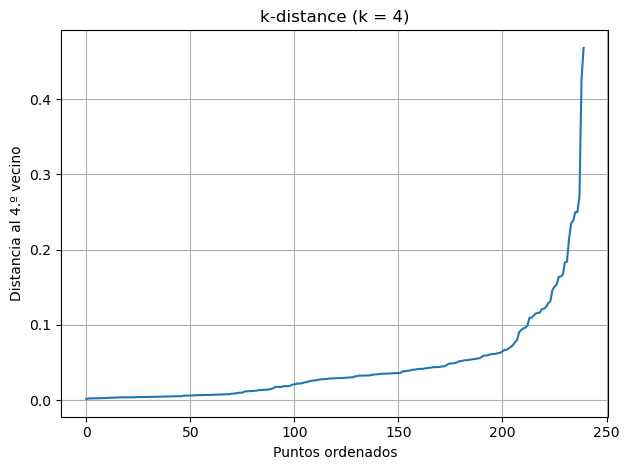

In [123]:
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_pca)
# Distancia al 4.º vecino más cercano de cada punto
distances, _ = nn.kneighbors(X_pca)
k_distances = np.sort(distances[:, -1])          
plt.figure()
plt.plot(k_distances)
plt.title(f'k-distance (k = {min_samples})')
plt.xlabel('Puntos ordenados'); plt.ylabel('Distancia al 4.º vecino')
plt.grid(); plt.tight_layout(); plt.show()



Esta gráfica muestra nuestros elementos ordenados de menos a mayor distancia con respecto a sus 4 vecinos, a más distancia, entorno menos denso y a menor, más denso. A partir de aproximadamente el punto 200 comienzan las muestras más aisladas.

Podemos ver que aproximadamente el 80% o el 90% de nuestros datos se encuentran juntos en áreas de mucha densidad, por lo que utilizaremos éstos datos como rango eps.

In [124]:
eps_min = np.percentile(k_distances, 80)  
eps_max = np.percentile(k_distances, 90)  
eps_grid = np.linspace(eps_min, eps_max, 20) 

results = []
total_samples = len(X_pca) 

# Grid search sobre eps 
for eps in eps_grid:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_pca)

    # nº clusters (sin contar ruido) y nº puntos etiquetados como ruido
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = np.sum(labels == -1)

    # Silhouette: solo si hay >= 2 clusters reales
    if n_clusters >= 2:
        sil = silhouette_score(X_pca[labels != -1], labels[labels != -1])
    else:
        sil = np.nan

    results.append((eps, n_clusters, n_noise, sil))

res_db = pd.DataFrame(
    results, columns=['eps', 'clusters', 'noise', 'silhouette']
)


display(res_db)


,eps,clusters,noise,silhouette
0,0.059249,11,35,0.712581
1,0.062067,10,32,0.696704
2,0.064884,10,30,0.691858
3,0.067701,9,30,0.650376
4,0.070519,8,30,0.643528
5,0.073336,8,30,0.643528
6,0.076153,7,30,0.712107
7,0.078971,7,27,0.700250
8,0.081788,7,27,0.700250
9,0.084605,7,27,0.700250


Podemos ver que el mejor valor se encuentra en nuestra sexta fila con la máxima compactación y un eps de 0.076153.
7 clusters y un silhouette de 0.712107, uno de los mas altos.

In [125]:
best_idx = 6 

best_eps = res_db.loc[best_idx, 'eps']
best_sil = res_db.loc[best_idx, 'silhouette']
best_clusters = int(res_db.loc[best_idx, 'clusters'])
best_noise = int(res_db.loc[best_idx, 'noise'])

print(f"Fila {best_idx}")
print(f"Eps = {best_eps:.3f} | clusters = {best_clusters} | ruido = {best_noise} | silhouette = {best_sil:.3f}")

Fila 6
Eps = 0.076 | clusters = 7 | ruido = 30 | silhouette = 0.712



Hacemos uso de la gráfica para fijarnos bien en los clusters seleccionados por éste método. 
(He usado IA generativa para ayudarme a hacer la gráfica)

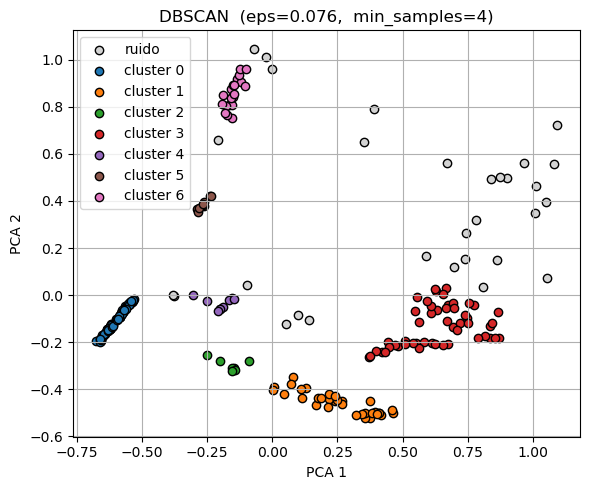

In [126]:

db_best   = DBSCAN(eps=best_eps, min_samples=min_samples)
labels_db = db_best.fit_predict(X_pca)

plt.figure(figsize=(6, 5))
unique_lab = np.unique(labels_db)
for lab in unique_lab:
    mask = labels_db == lab
    if lab == -1:           
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c='lightgrey', edgecolor='k', label='ruido')
    else:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=f'cluster {lab}', edgecolor='k')

plt.title(f'DBSCAN  (eps={best_eps:.3f},  min_samples={min_samples})')
plt.xlabel('PCA 1'); plt.ylabel('PCA 2')
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()


### ¿Cuál de los métodos captura mejor la estructura de los clusters?

Basándonos en la métrica del coeficiente de silueta (*Silhouette Score*), los mejores resultados para cada modelo son los siguientes:

- **DBSCAN:** 0.712 (con k = 7)
- **K-Means:** 0.6432 (con k = 3)
- **Clustering Jerárquico:** 0.6605  (con k = 8, average)

Teniendo estos datos en cuenta, observamos que el valor más alto lo obtiene el método de **DBSCAN** (con K = 7). Matemáticamente, esto indica que es el algoritmo que consigue los clusters más densos y mejor separados entre sí.

Ahora mediremos nuestro modelo con las clases reales

Adjusted Rand Index (Jerárquico vs. clase): 0.526


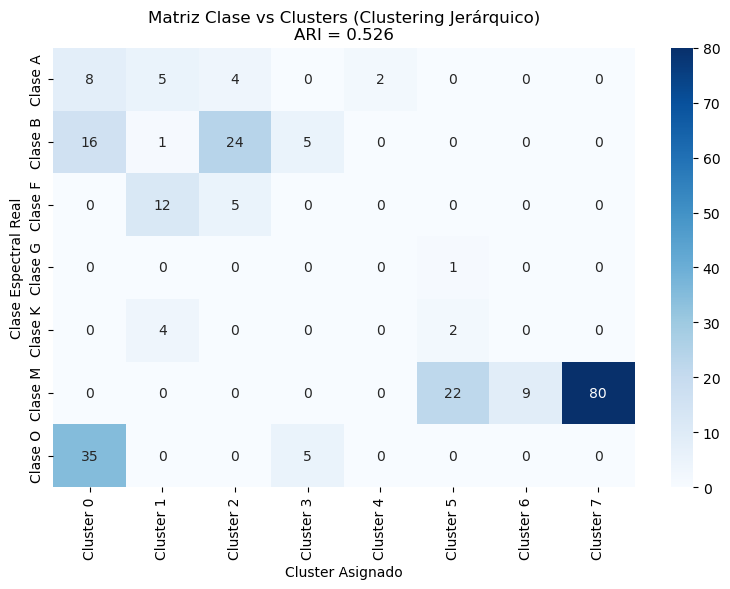

In [133]:
from sklearn.metrics import adjusted_rand_score, confusion_matrix
import seaborn as sns

# ARI
ari = adjusted_rand_score(y, best_labels)
print(f"Adjusted Rand Index (Jerárquico vs. clase): {ari:.3f}")

# Obtenemos las etiquetas únicas de cada eje
# Usamos 'y' directamente para tener los nombres 
true_labels_names = np.sort(y.unique())           
pred_labels_ids = np.sort(np.unique(best_labels)) 

# Calculamos la matriz cruzando Clases (letras) vs Clusters (números)
# Convertimos a string para evitar el error de tipos
labels_aux = np.concatenate([true_labels_names.astype(str), pred_labels_ids.astype(str)])
cm_full = confusion_matrix(y.astype(str), best_labels.astype(str), labels=labels_aux)

# Extraemos el bloque de Clase vs Cluster (recortamos los ceros sobrantes)
n_clases = len(true_labels_names)
cm_final = cm_full[:n_clases, n_clases:]

# Creamos el DataFrame con los nombres reales en las filas
df_cm = pd.DataFrame(
    cm_final,
    index   = [f"Clase {c}"   for c in true_labels_names], 
    columns = [f"Cluster {c}" for c in pred_labels_ids]    
)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz Clase vs Clusters (Clustering Jerárquico)\nARI = {ari:.3f}")
plt.ylabel("Clase Espectral Real")
plt.xlabel("Cluster Asignado")
plt.tight_layout()
plt.show()

En esta matriz podemos ver el tipo de estrellas que ha capturado cada cluster.

Podemos ver como el cluster 0 ha podido capturar la mayor cantidad de estrellas de clase O pero tambien ha metido en su mismo grupo a los de clase B y A. El cluster 1 con elementos tanto de clase F como A y el cluster 2 con un gran acierto en las estrellas de tipo B. Destacamos también los clusters 3, 4 que apenas han agrupado estrellas y como el cluster 5, 6 y 7 podrían haber sido 1 solo cluster ya que todos han agrupado estrellas de clase M (El 7 con más precisión).
Éste método ha acertado en el número de clusters pero no ha capturado bien las estrellas de clase G y K

Podemos probar por el método de DBSCAN

Adjusted Rand Index (DBSCAN vs. clase): 0.501


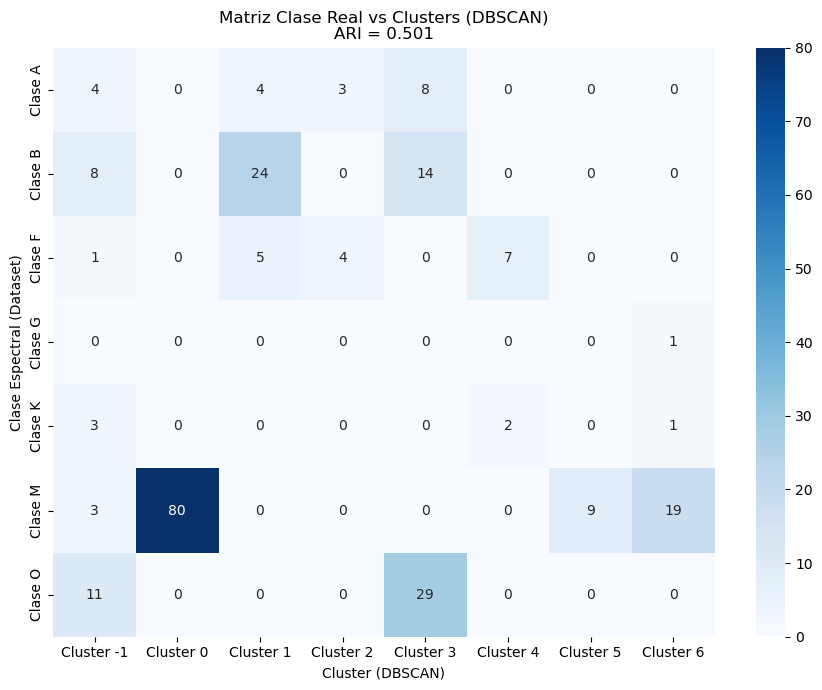

In [134]:
# ARI 
ari = adjusted_rand_score(y, labels_db)
print(f"Adjusted Rand Index (DBSCAN vs. clase): {ari:.3f}")

# Definimos las etiquetas de filas y columnas
true_labels_names = np.sort(y.unique())               
pred_labels_ids = np.sort(np.unique(labels_db))      

# Convertimos todo a string para que union/concatenate no den el error de tipos
labels_para_cm = np.concatenate([true_labels_names.astype(str), pred_labels_ids.astype(str)])

# Calculamos la matriz completa 
cm = confusion_matrix(y.astype(str), labels_db.astype(str), labels=labels_para_cm)

n_clases = len(true_labels_names)
cm_reducida = cm[:n_clases, n_clases:]

# Creamos el DataFrame con los nombres reales
df_cm = pd.DataFrame(
    cm_reducida,
    index   = [f"Clase {c}"   for c in true_labels_names],
    columns = [f"Cluster {c}" for c in pred_labels_ids]
)

# Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz Clase Real vs Clusters (DBSCAN)\nARI = {ari:.3f}")
plt.ylabel("Clase Espectral (Dataset)")
plt.xlabel("Cluster (DBSCAN)")
plt.tight_layout()
plt.show()

Éste método ha acertado en el numero de clusters pero al igual que el anterior no ha sabido agrupar bien las estrellas de clase K y G. El cluster 0 ha podido agrupar a la perfeccion las estrellas de clase M, el 1 una gran cantidad de las de clase B, pero no todas. El cluster 3 es el equivalente al cluster 0 del anterior.
Una característica a destacar con respecto al método anterior es que el método ha considerado una gran cantidad de estrellas de clase O como ruido, al igual que la mitad de las estrellas de clase K

 Si utilizamos k-means con un K = 3:

Adjusted Rand Index (K-Means vs. clase): 0.381


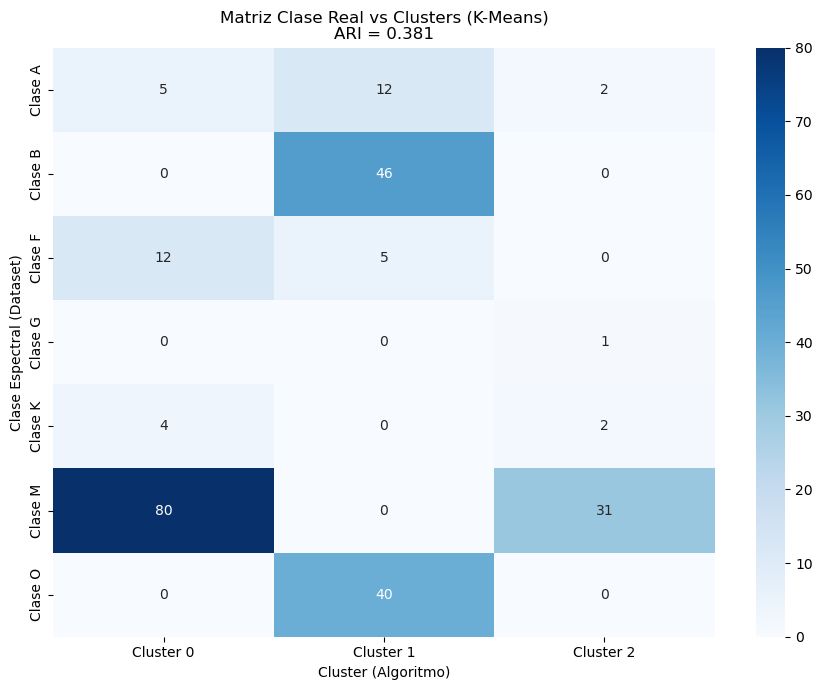

In [129]:
ari = adjusted_rand_score(y, kmeans_labels)
print(f"Adjusted Rand Index (K-Means vs. clase): {ari:.3f}")

true_labels_names = np.sort(y.unique()) 
pred_labels_ids = np.sort(np.unique(kmeans_labels))
all_labels_str = np.concatenate([true_labels_names.astype(str), pred_labels_ids.astype(str)])

# Calculamos la matriz completa
cm = confusion_matrix(y.astype(str), kmeans_labels.astype(str), labels=all_labels_str)

# Extraemos Clases vs Clusters
n_clases = len(true_labels_names)
cm_reducida = cm[:n_clases, n_clases:]

# Creamos el DataFrame para el Heatmap con los nombres corregidos
df_cm = pd.DataFrame(
    cm_reducida,
    index   = [f"Clase {c}" for c in true_labels_names], 
    columns = [f"Cluster {c}" for c in pred_labels_ids]   
)

# Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz Clase Real vs Clusters (K-Means)\nARI = {ari:.3f}")
plt.ylabel("Clase Espectral (Dataset)")
plt.xlabel("Cluster (Algoritmo)")
plt.tight_layout()
plt.show()

Falla con el numero de clusters final. 

Si por el contrario utilizamos el K = 7 que teníamos tambien como posibilidad nos queda de la siguiente manera

Adjusted Rand Index (K-Means k=7 vs. clase): 0.516


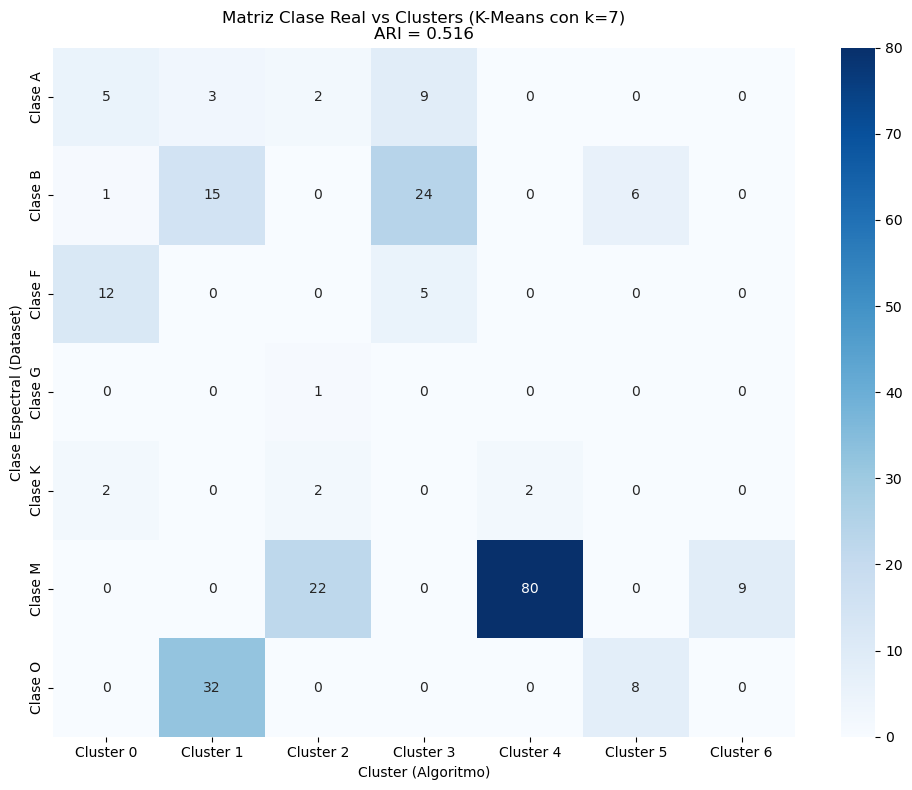

In [135]:


# Ejecutamos K-Means con k=7
kmeans = KMeans(n_clusters=7, random_state=SEMILLA, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca)

# ARI 
ari = adjusted_rand_score(y, kmeans_labels)
print(f"Adjusted Rand Index (K-Means k=7 vs. clase): {ari:.3f}")

# Preparación de etiquetas para la Matriz
true_labels_names = np.sort(y.unique())           
pred_labels_ids = np.sort(np.unique(kmeans_labels))

# Convertimos a string para evitar errores de tipo al concatenar
labels_aux = np.concatenate([true_labels_names.astype(str), pred_labels_ids.astype(str)])

# Calculamos la matriz completa y recortamos (Clases vs Clusters)
cm = confusion_matrix(y.astype(str), kmeans_labels.astype(str), labels=labels_aux)
n_clases = len(true_labels_names)
cm_reducida = cm[:n_clases, n_clases:]

# Creamos el DataFrame
df_cm = pd.DataFrame(
    cm_reducida,
    index   = [f"Clase {c}" for c in true_labels_names], 
    columns = [f"Cluster {c}" for c in pred_labels_ids]   
)

# Dibujamos el Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz Clase Real vs Clusters (K-Means con k=7)\nARI = {ari:.3f}")
plt.ylabel("Clase Espectral (Dataset)")
plt.xlabel("Cluster (Algoritmo)")
plt.tight_layout()
plt.show()

Vemos como con el número de clusters correcto acierta muchas más veces a la hora de agrupar tipos de estrellas.
El cluster 4 selecciona a la perfeccion estrellas del tipo M aunque existen otros clusters como el 6 o el 2 que también capturan estrellas de ese tipo. Con respecto al resto de clusters podemos afiermar que es muy similar con respecto de otros métodos.

Parece que todos los métodos han fallado a la hora de agrupar estrellas de tipo K y G, la razón puede ser el reducido número de estrellas de esos tipos.

Por último interpretamos los clusters optenidos de K_means con boxplot:

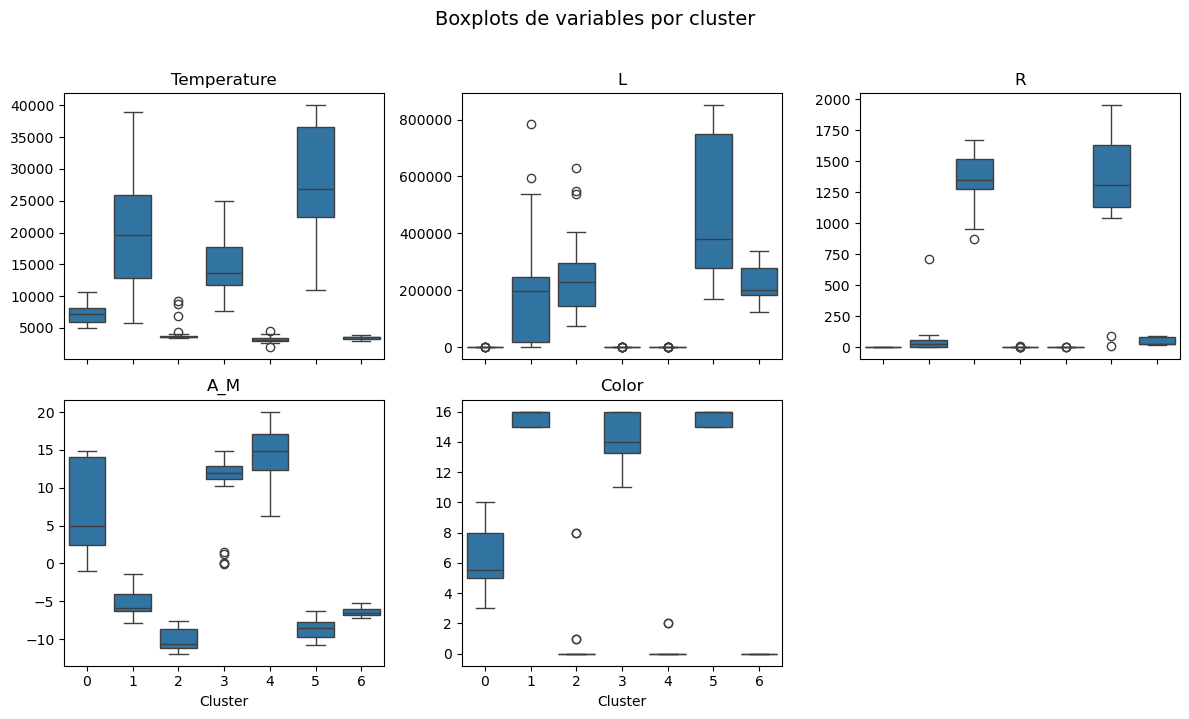

In [136]:


# mi mejor algoritmo
label_set = kmeans_labels        

vars_originales = X.columns.tolist()  
n_vars = len(vars_originales)
n_cols = 3                                  
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows), sharex=True)
axes = axes.flatten()                        

for i, col in enumerate(vars_originales):
    sns.boxplot(x=label_set, y=data_df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel("")                 

for j in range(i+1, len(axes)):
    axes[j].axis('off')

fig.suptitle("Boxplots de variables por cluster", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



En definitiva, podemos ver como pese a que el método con mayor índice de silhouette sea DBSCAN parece que es el clustering gerárquico el que mejor agrupa las clases de las estrellas, ya que muchas de ellas no las considera ruido y las asigna correctamente a un cluster.